# Projekt z zakresu analizy danych

autorzy: Igor Rybiński, Jakub Przemski 

rok akademicki: 2024/2025


### O zbiorze danych:

Zbiór danych zawiera dane od 2000 studentów zebrane przez ankietę na Google Forms. Zawiera informacje o 

-   godzinach uczenia się (Study_Hours_Per_Day)

-   zajęciach pozalekcyjnych (Extracurricular_Activities_Per_Day)

-   długości snu (Sleep_Hours_Per_Day)

-   godzinach spędzonych z ludźmi (Social_Hours_Per_Day)

-   aktywności fizycznej (Phisical_Activity_Hours_Per_Day)

-   ocenach (GPA)

-   poziomie stresu (Stress_Level)


Nazwa pliku: Daily_Lifestyle_and_Academic_Performance.csv

Format pliku: csv

Liczba wierszy: 2000

Liczba kolumn: 8

Autor zbioru: Sumit Kumar

### Cel Projektu: 

Przewidywanie poziomu stresu uczniów na podstawie danych dotyczących ich stylu życia oraz wyników w nauce

### Struktura raportu:

1. **Wprowadzenie**
    - Autorzy
    - Cel projektu
    - Opis zbioru danych

2. **Wczytanie danych**
    - Importowanie bibliotek
    - Wczytanie danych z pliku CSV
    - Sprawdzenie braków danych

3. **Analiza danych**
    - Statystyki opisowe
    - Rozkłady zmiennych
        - Histogramy
        - Wykresy pudełkowe
    - Macierz korelacji

4. **Przetwarzanie danych**
    - Identyfikacja i usuwanie wartości odstających
    - Obliczanie wariancji
    - Wykrywanie anomalii
    - Usuwanie anomalii
    - Zapisanie przetworzonych danych

5. **Modelowanie**
    - Wstępne uczenie modelu
    - Zrównoważenie danych za pomocą ADASYN
    - Tworzenie właściwego modelu

6. **Wyniki**
    - Ocena modelu
    - Interpretacja wyników

7. **Redukcja danych**
    - PCA
    - ICA
    - ocena modeli po redukcji wymiarów

8. **Podsumowanie**
    - Kluczowe wnioski
    - Możliwe dalsze kroki

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
import seaborn as sns
import pycaret.anomaly as anl
import pycaret.classification as cls
import statsmodels.api as sm
import plotly.express as px
from pycaret.classification import set_current_experiment
from imblearn.over_sampling import ADASYN
from sklearn.tree import plot_tree
from sklearn.inspection import PartialDependenceDisplay
from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D


**Wczytanie danych**

In [63]:
dane=pd.read_csv("student_lifestyle_dataset.csv")

**Sprawdzenie czy występują braki danych**

In [64]:
dane.isnull().sum()

Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
GPA                                0
Stress_Level                       0
dtype: int64

W zbiorze nie występują braki danych

## Statystyki opisowe

In [65]:
dane.describe()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000


In [66]:
dane.dtypes

Student_ID                           int64
Study_Hours_Per_Day                float64
Extracurricular_Hours_Per_Day      float64
Sleep_Hours_Per_Day                float64
Social_Hours_Per_Day               float64
Physical_Activity_Hours_Per_Day    float64
GPA                                float64
Stress_Level                        object
dtype: object

## Rozkłady zmiennych

### Histogramy

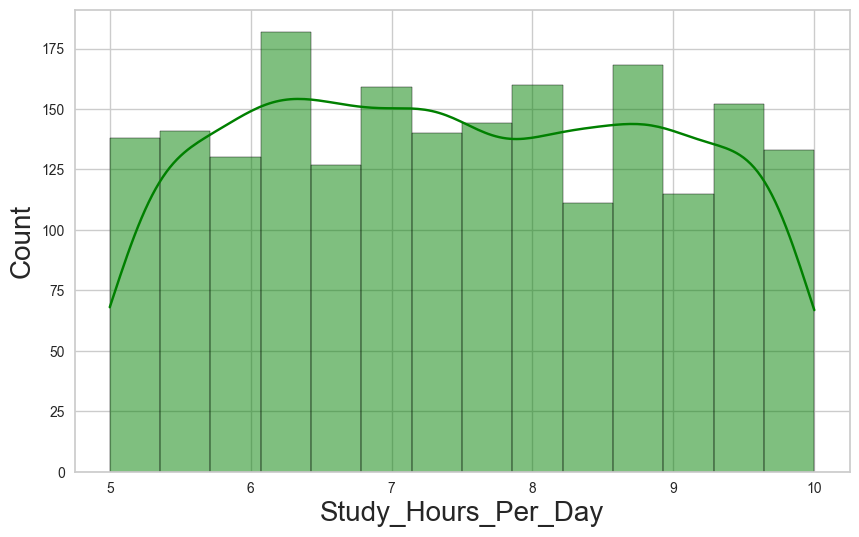

In [67]:
plt.figure(figsize=(10,6))
sns.histplot(data=dane, x="Study_Hours_Per_Day", kde=True, color='green')
plt.xlabel("Study_Hours_Per_Day", fontsize=20)
plt.ylabel("Count", fontsize=20)
plt.show()

Wykres przedstawia rozkład godzin nauki na dzień. Większość osób uczy się od 6 do 9 godzin.

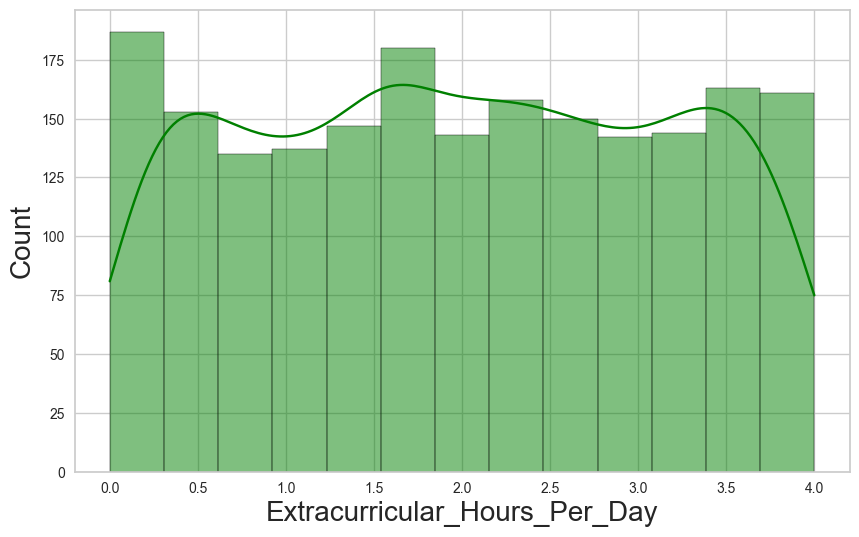

In [68]:
plt.figure(figsize=(10,6))
sns.histplot(data=dane, x="Extracurricular_Hours_Per_Day",kde=True, color='green')
plt.xlabel("Extracurricular_Hours_Per_Day", fontsize=20)
plt.ylabel("Count", fontsize=20)
plt.show()

Wykres przedstawia rozkład godzin zajęć pozalekcyjnych na dzień. Rozkład jest w miarę jednostajny. Długość zajęć pozalekcyjnych wynosi od 0 do 4 godzin.

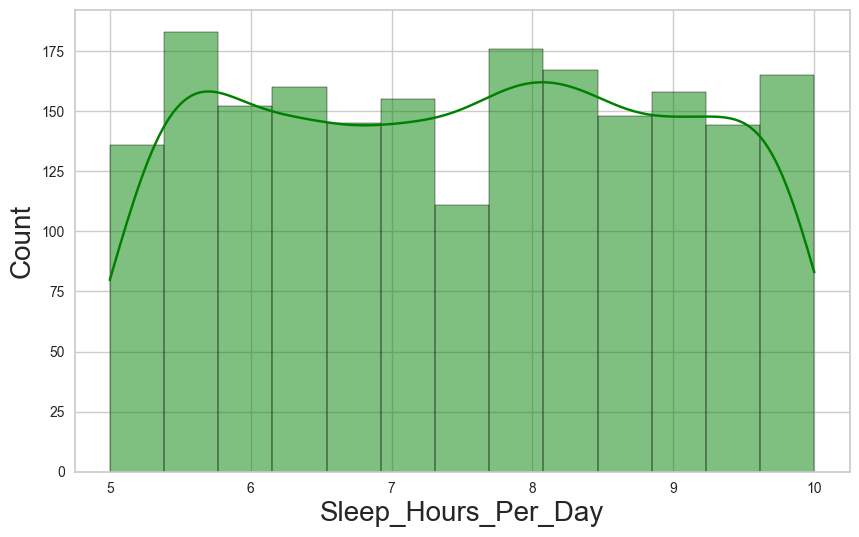

In [69]:
plt.figure(figsize=(10,6))
sns.histplot(data=dane, x="Sleep_Hours_Per_Day", kde=True, color='green')
plt.xlabel("Sleep_Hours_Per_Day", fontsize=20)
plt.ylabel("Count", fontsize=20)
plt.show()

Wykres przedstawia rozkład godzin snu na dzień. Badane osoby śpią od 5 do 10 godzin. Ludzi spiących 7.5 godziny (średnia godzin snu) jest najmniej, co może oznaczać że ludzie dzielą się na 2 grupy: śpiących bardzo długo oraz śpiących bardzo krótko.

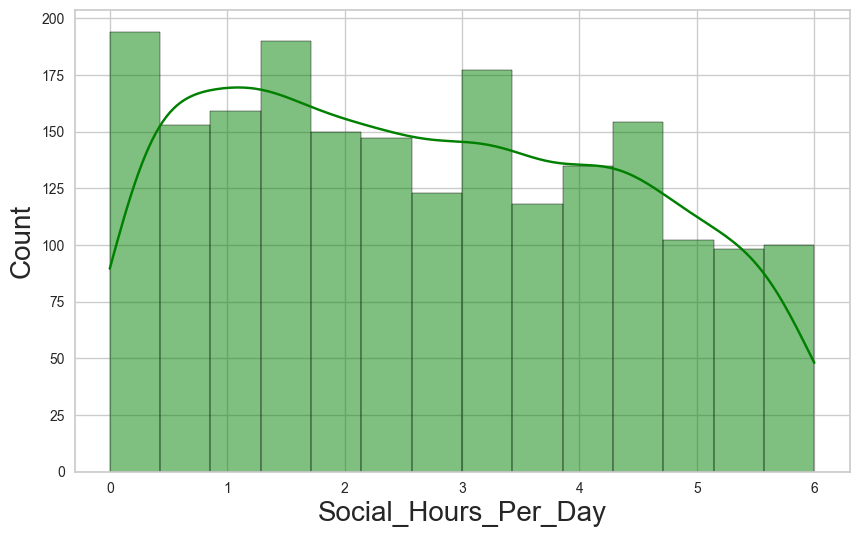

In [70]:
plt.figure(figsize=(10,6))
sns.histplot(data=dane, x="Social_Hours_Per_Day", kde=True, color='green')
plt.xlabel("Social_Hours_Per_Day", fontsize=20)
plt.ylabel("Count", fontsize=20)
plt.show()

Wykres przedstawia rozkład godzin spędzonych w towarzystwie innych. Rozkład jest prawostronnie asymetryczny. Najczęściej ludzie spędzają towarzysko poniżej 1 godziny, najrzadziej powyżej 5 godzin.

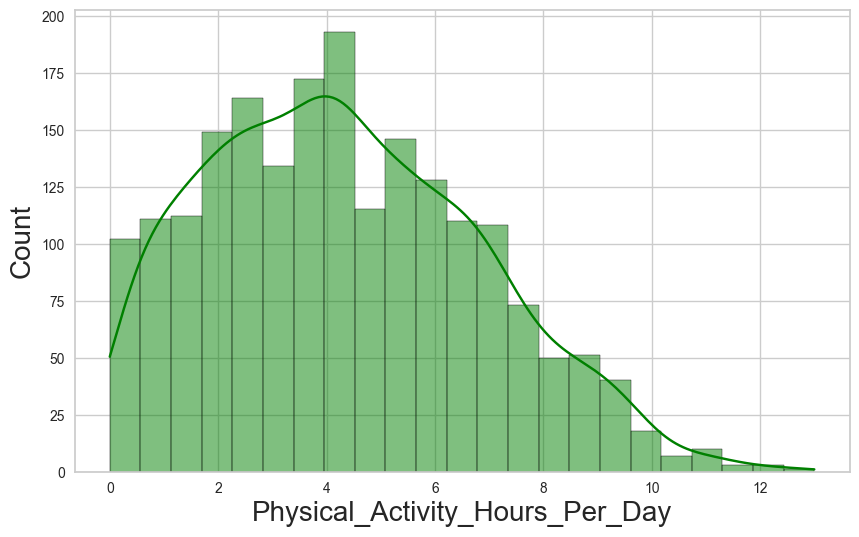

In [71]:
plt.figure(figsize=(10,6))
sns.histplot(data=dane, x="Physical_Activity_Hours_Per_Day", kde=True, color='green')
plt.xlabel("Physical_Activity_Hours_Per_Day", fontsize=20)
plt.ylabel("Count", fontsize=20)
plt.show()

Histogram aktywności fizycznej w ciągu dnia jest prawostronnie asymetryczny. Najwięcej osób jest aktywna fizycznie około 4 godzin w ciągu dnia.

In [72]:
print(st.skew(dane.Physical_Activity_Hours_Per_Day))

0.3989397254830713


Skośność większa od zera potwierdza prawostronną asymetryczność rozkładu.

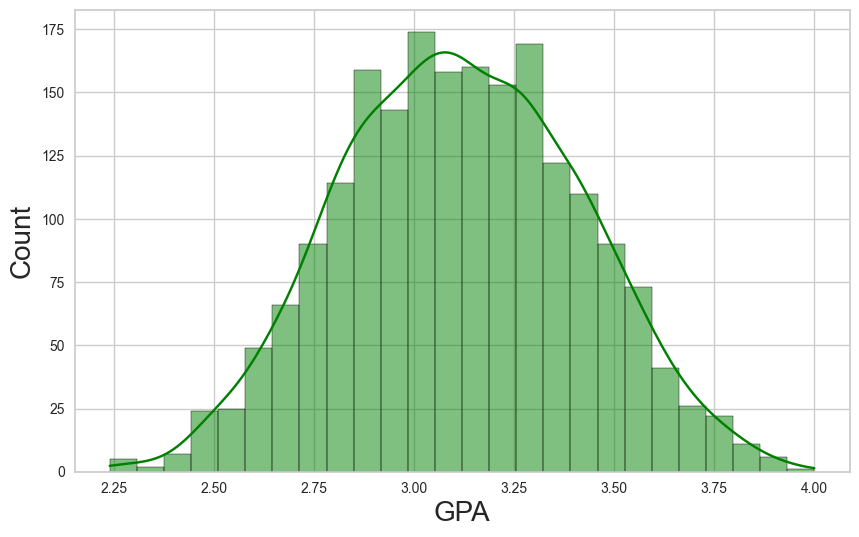

In [73]:
plt.figure(figsize=(10,6))
sns.histplot(data=dane, x="GPA", kde=True, color='green')
plt.xlabel("GPA", fontsize=20)
plt.ylabel("Count", fontsize=20)
plt.show()

Rozkład ocen przypomina rozkład normalny. Najwięcej osób ma oceny blisko średniej równej 3.12

In [74]:
print(st.shapiro(dane.GPA))

ShapiroResult(statistic=0.9974928498268127, pvalue=0.002785765565931797)


Preprowadziliśmy test Shapiro-Wilka. p-value jest mniejszę od 0.05 zatem odrzucamy hipotezę o tym, że rozkład zmiennej GPA jest rozkładem normalnym

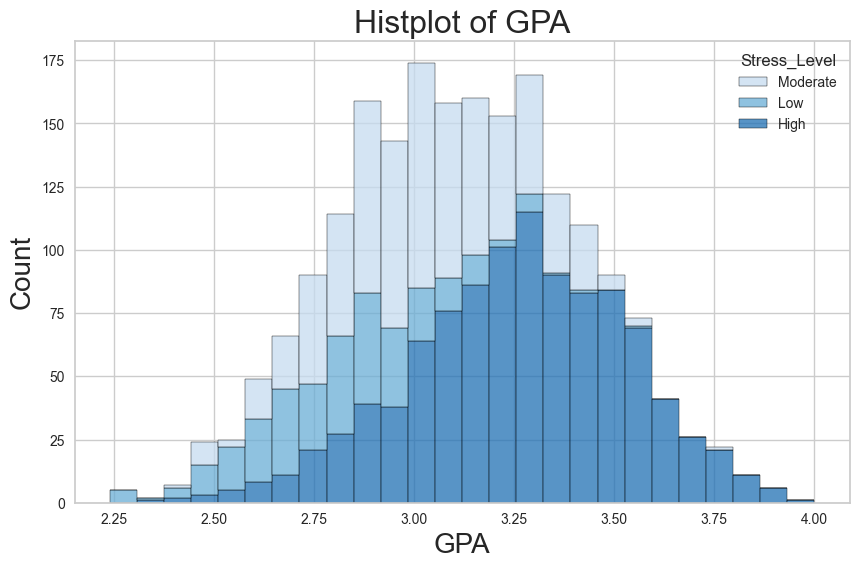

In [75]:
plt.figure(figsize=(10,6))
plt.xlabel("GPA", fontsize=20)
plt.ylabel("Count", fontsize=20)
plt.title("Histplot of GPA", fontsize=23)
sns.histplot(data=dane, x="GPA", palette='Blues', hue='Stress_Level', multiple='stack')
plt.show()

Na Histogramie z podziałem na poziomy stresu możemy zauważyć, że osoby z większym poziomem stresu mają średnio lepsze oceny.

In [76]:
average_gpa_per_stress_level = dane.groupby('Stress_Level')['GPA'].mean()
print(average_gpa_per_stress_level)

Stress_Level
High        3.261973
Low         2.816869
Moderate    3.024837
Name: GPA, dtype: float64


Średnia ocen dla każdej grupy jest inna.

### Wykresy pudełkowe

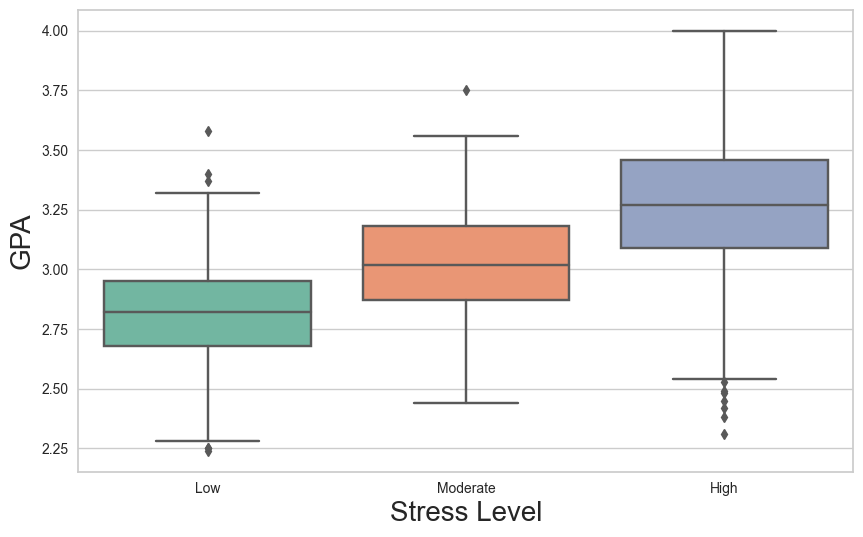

In [77]:
plt.figure(figsize=(10,6))
sns.boxplot(data=dane, x='Stress_Level', y='GPA', palette='Set2', order=['Low', 'Moderate', 'High'])
plt.xlabel("Stress Level", fontsize=20)
plt.ylabel("GPA", fontsize=20)
plt.show()

Wykres pudełkowy potwierdza wcześniejsze obserwacje. Widać, że oceny różnią się w zależności od poziomu stresu. Osoby z wyższym poziomem stresu mają średnio lepsze oceny.

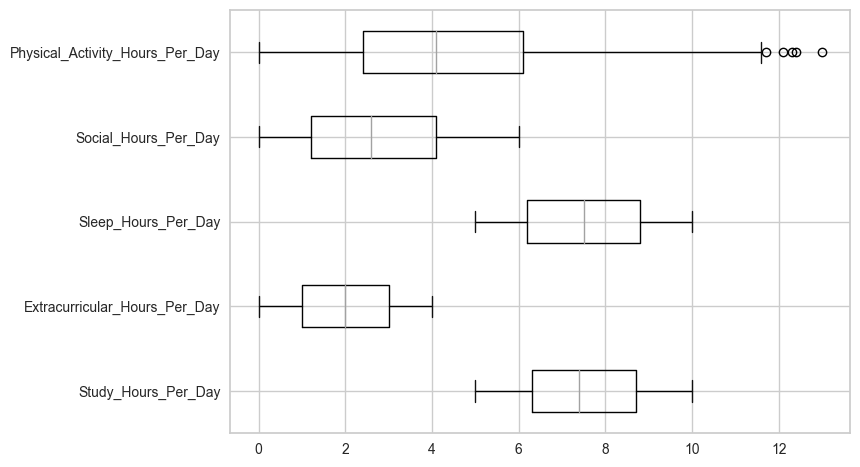

In [78]:
dane = dane.drop("Student_ID", axis = 1)
dane.drop("GPA", axis=1).boxplot(vert = False)
plt.show()

Wykres przedstawia wykresy pudełkowe dla każdej zmiennej opisanej w skali godzinowej. Możemy zaobserwować, że sen i godziny nauki mają bardzo podobny rozkład. Największą zróżnicowanie widać w godzinach poświęconych na aktywność fizyczną. Na wykresie widać również wartości odstające przy zmiennej Phisical_Activity_Hours_Per_Day


## Dystrybucja danych między klasami

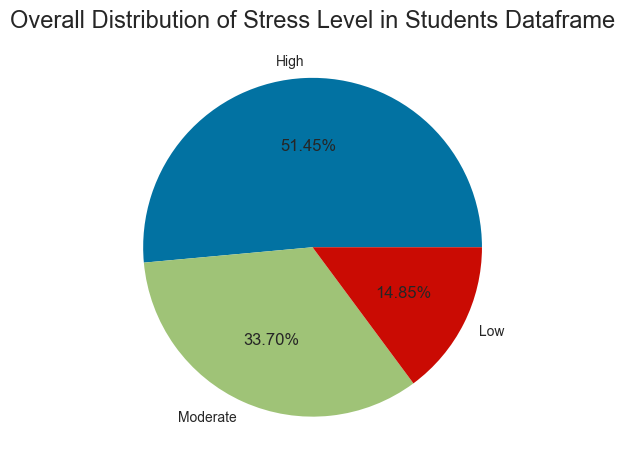

In [79]:
stress_count = dane['Stress_Level'].value_counts()

plt.pie(stress_count, labels = ['High', 'Moderate', 'Low'], autopct='%2.2f%%')
plt.title('Overall Distribution of Stress Level in Students Dataframe', fontsize=17)
plt.show()

Mamy doczynienia z niezbalansowanym zbiorem danych. Większość osób (51.45%) posiada wysoki poziom stresu. Osoby ze średnim poziomem stresu stanowią 33.70% zbioru danych, a osoby z niskim poziomem stresu jedynie 14.85%.

## Wstępne uczenie pierwszego modelu

Jak wcześniej zauważono, dane nie są zrównoważone, co sprawia, że stworzenie na ich podstawie modelu klasyfikacyjnego nie jest optymalnym podejściem. Mimo to, w ramach wstępnej analizy, zdecydujemy się na takie rozwiązanie, aby uzyskać przybliżone wyniki modelu oraz dokonać interpretacji wskaźnika F1-score. Nawet w przypadku niezrównoważonych danych, F1-score dostarcza wartościowych informacji o wydajności modelu, uwzględniając równocześnie precyzję i czułość.

In [80]:
exp_clf101 = cls.setup(data = dane, normalize=True, target = 'Stress_Level', session_id=123) 
cls.compare_models()

,Description,Value
0,Session id,123
1,Target,Stress_Level
2,Target type,Multiclass
3,Target mapping,"High: 0, Low: 1, Moderate: 2"
4,Original data shape,"(2000, 7)"
5,Transformed data shape,"(2000, 7)"
6,Transformed train set shape,"(1400, 7)"
7,Transformed test set shape,"(600, 7)"
8,Numeric features,6
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dt,Decision Tree Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0100
rf,Random Forest Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0440
ada,Ada Boost Classifier,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0250
gbc,Gradient Boosting Classifier,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0780
xgboost,Extreme Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0180
lightgbm,Light Gradient Boosting Machine,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0870
et,Extra Trees Classifier,0.9821,0.9994,0.9821,0.9825,0.9821,0.9701,0.9704,0.0420
knn,K Neighbors Classifier,0.9014,0.9746,0.9014,0.9013,0.9001,0.8338,0.8353,0.0140
qda,Quadratic Discriminant Analysis,0.8700,0.0000,0.8700,0.8817,0.8698,0.7845,0.7917,0.0090
nb,Naive Bayes,0.8529,0.9479,0.8529,0.8600,0.8528,0.7590,0.7622,0.0110


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, random_state=123, splitter='best')

W trakcie porównywania różnych wariantów modeli za pomocą biblioteki PyCaret, wyniki zostały oszacowane przy użyciu walidacji krzyżowej z 10 foldami. Każdy zbiór testowy składał się z 568 obserwacji, a zbiór treningowy z 1323.

Rezultaty okazały się zaskakujące – sześć modeli osiągnęło zarówno Accuracy, jak i F1-score równe 1. Oznacza to, że modele te nie popełniły żadnego błędu podczas klasyfikacji w zbiorach testowych. Warto jednak podkreślić, że w obecnym kontekście Accuracy nie jest najlepszą miarą skuteczności modeli, szczególnie przy niezrównoważonych danych. Niemniej, tak wysokie wyniki F1-score sugerują, że modele doskonale radzą sobie z równoczesnym uwzględnieniem precyzji i czułości, gdzie:

## Czułość (Recall)

$$Recall=\frac{TP}{TP + FN}$$

Gdzie TP to True Positive (liczba dobrze zaklasyfikowanych wartości pozytywnych), a FN to False Negative(liczba niepoprawnie zaklasyfikowanych wartości negatywnych). W naszym przypadku jednak nie można mówić o przypadkach pozytywnych i negatywnych, ponieważ klasyfikacja nie jest binarna. W takim scenariuszu Recall oblicza się trzykrotnie, za każdym razem traktując inną klasę jako pozytywną. Ostateczny wynik jest średnią z trzech uzyskanych wartości. Analogicznie postępuje się w przypadku Precision oraz F1-score.

## Precyzja (Precision)

$$Precision=\frac{TP}{TP+FP}$$

Gdzie FP to False Positive czyli niepoprawnie zaklasyfikowany przypadek pozytywny.


## F1-score

$$F1=2*\frac{Precision*Recall}{Precision+Recall}$$

Czyli średnia harmoniczna czułości i precyzji.

In [81]:
dt = cls.create_model('dt')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

Tworzymy najprostszy model – drzewo decyzyjne – aby jak najłatwiej było wyjaśnić jego działanie. Jak można zauważyć, podczas walidacji krzyżowej z zastosowaniem 10 foldów, za każdym razem uzyskane miary były idealne, osiągając wartość 1. Oznacza to, że model klasyfikował dane bezbłędnie w każdym przypadku.

## Wartości odstające

In [82]:
def identify(dane):
    columns = dane.columns.tolist()
    columns.remove("Stress_Level")
    filtered_data = dane.copy()
    for col in columns:    
        Q1 = np.percentile(dane[col], 25)
        Q3 = np.percentile(dane[col], 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        filtered_data = filtered_data[(filtered_data[col] >= lower_bound) & (filtered_data[col] <= upper_bound)]

    return filtered_data

dane_czyste = identify(dane)
print(dane_czyste.shape)

(1991, 7)


Powyższa funkcja identyfikuje wartości odstające w podanym zbiorze danych i zwraca zbiór oczyszczony z tych obserwacji. Dla każdej kolumny (z wyjątkiem kolumny "Stress_Level") obliczane są kwartyle $Q1$ (pierwszy kwartyl) i $Q3$ (trzeci kwartyl). Następnie wyznaczana jest odległość między kwartylami, czyli różnica $Q3−Q1$, zwana zakresem międzykwartylowym ($IQR$). Na tej podstawie obliczane są dolna ($Q1−1.5⋅IQR$) i górna granica ($Q3+1.5⋅IQR$). Do zbioru wynikowego dodawane są tylko te obserwacje, które mieszczą się w granicach dla wszystkich analizowanych kolumn. W naszym zbiorze występuje 9 wartości odstających ponieważ rozmiar zbioru zmniejszył się z 2000 wierszy na 1991.

## Wariancja

In [83]:
dane_czyste.select_dtypes(include=['number']).var()

Study_Hours_Per_Day                2.015162
Extracurricular_Hours_Per_Day      1.334210
Sleep_Hours_Per_Day                2.135805
Social_Hours_Per_Day               2.842023
Physical_Activity_Hours_Per_Day    6.174496
GPA                                0.087607
dtype: float64

Za pomocą powyższego kodu obliczamy wariancje w każdej kolumnie. Można zauważyć, że wariancja ocen jest bardzo mała, wynosi ona zaledwie około 0.087,oznacza to,że wartości są silnie skocentrowane wokół średniej, co może sugerować niewielkie różnice w ocenach. Największą wariancje ma kolumna mówiąca o liczbie godzin poświęconych na aktywność fizyczną, równą 6.31, wskazuje to na dużą różnorodność w ilości czasu poświęcanego na ćwiczenia fizyczne przez studentów.

## Macierz korelacji

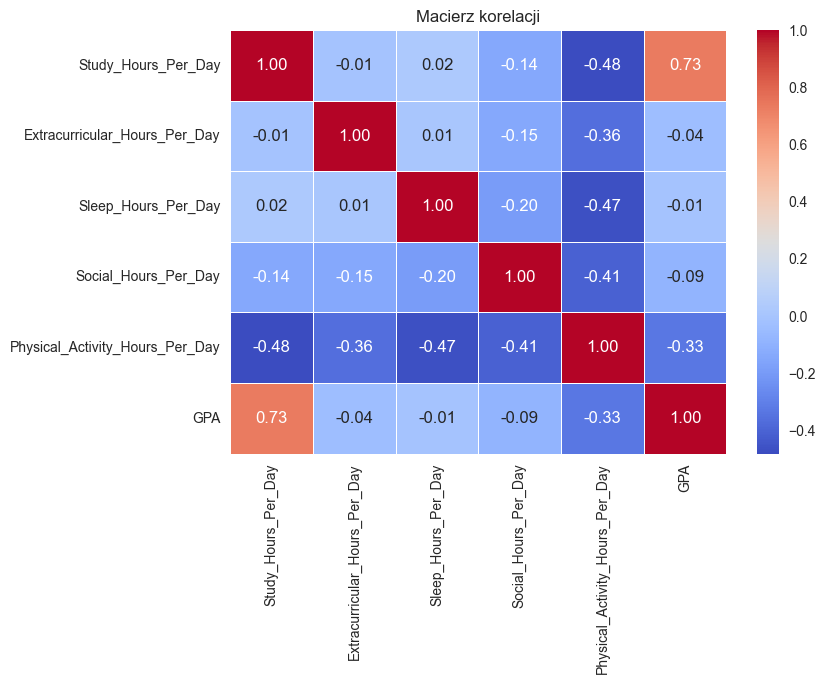

In [84]:
kor_mat = dane_czyste.select_dtypes(include=['number']).corr()
sns.heatmap(kor_mat, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Macierz korelacji')  
plt.show()

Powyższy wykres przedstawia macierz korelacji zmiennych, którą opracowaliśmy w celu rozważenia usunięcia zmiennej GPA. Poniżej zapisaliśmy kluczowe wnioski wynikające z analizy:

* Zmienna GPA wykazuje dość silną dodatnią korelację z czasem poświęconym na naukę – współczynnik korelacji wynosi 0,73. Oznacza to, że im więcej czasu studenci poświęcają na naukę, tym lepsze średnio osiągają oceny. Można również stwierdzić, że zmienna Study_Hours_Per_Day wyjaśnia znaczną część wariancji zmiennej GPA, co dodatkowo sugeruje wyelimnowanie zmiennej GPA.

* Zmienna oznaczająca czas poświęcony na aktywność fizyczną wykazuje umiarkowaną, ale znaczącą, ujemną korelację z pozostałymi zmiennymi. Sugeruje to, że uczniowie uprawiający dużo sportu mają mniej czasu na inne aktywności. Najbardziej kosztem aktywności fizycznej studenci ograniczają czas na naukę oraz sen, co znajduje odzwierciedlenie w korelacjach wynoszących odpowiednio -0,49 i -0,47.

Dodatkowo przypominamy, że zmienna GPA charakteryzuje się niską wariancją. Uwzględniając zarówno aspekt korelacji, jak i wariancji, podjęliśmy decyzję o usunięciu zmiennej GPA z dalszej analizy. Proces modelowania i analizy będzie kontynuowany bez uwzględnienia tej zmiennej.

## Zależność ocen od godzin nauki

In [85]:
Y = dane["GPA"]
X = dane["Study_Hours_Per_Day"]
X = sm.add_constant(X) 
regression_model = sm.OLS(Y,X)
results = regression_model.fit()

In [86]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.539
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     2340.
Date:                Tue, 14 Jan 2025   Prob (F-statistic):               0.00
Time:                        18:18:42   Log-Likelihood:                 354.75
No. Observations:                2000   AIC:                            -705.5
Df Residuals:                    1998   BIC:                            -694.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   1.9642    

Zbudowany model: 

$GPA = 0.1541 \cdot Study\_Hours + 1.9642 $

Z modelu wynika, że dodatkowa godzina nauki wpływa na wzrost oceny średnio o 0.15.

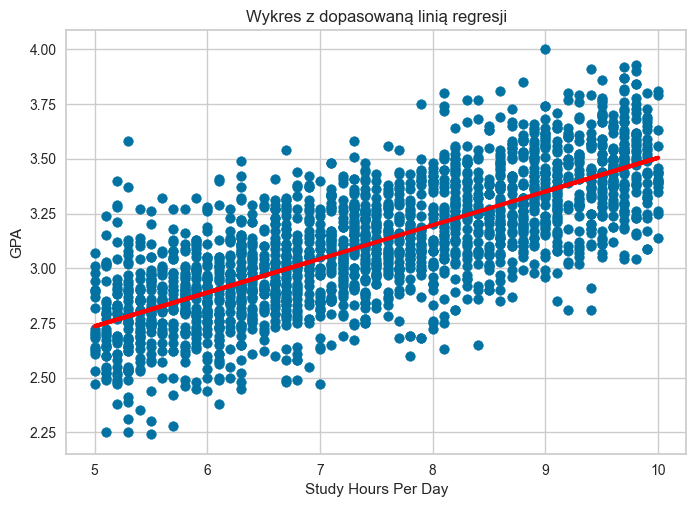

In [87]:
def myfunc(x):
  return results.params[1] * x + results.params[0]

plt.scatter(dane["Study_Hours_Per_Day"], dane["GPA"])
plt.plot(dane["Study_Hours_Per_Day"], myfunc(dane["Study_Hours_Per_Day"]), color="red",linewidth=3)
plt.title("Wykres z dopasowaną linią regresji")
plt.ylabel("GPA")
plt.xlabel("Study Hours Per Day")
plt.show()

In [88]:
print(f"rmse: {np.sqrt(results.mse_resid)}")
print(f"R^2: {results.rsquared}")

rmse: 0.2027435244291563
R^2: 0.5394432146089783


Model posiada współczynnik $R^2$ równy $0.539$ co oznacza, że jest raczej słabo dopasowany do danych

### Zapisanie danych bez GPA

In [89]:
dane_czyste = dane_czyste.drop(columns=['GPA'])

## Wykrywanie Anomali

In [90]:
exp_clf100 = anl.setup(data = dane_czyste, session_id=125) 
anomal = anl.create_model('abod')
labeled_data = anl.assign_model(anomal)

anl.plot_model(anomal)

,Description,Value
0,Session id,125
1,Original data shape,"(1991, 6)"
2,Transformed data shape,"(1991, 8)"
3,Numeric features,5
4,Categorical features,1
5,Preprocess,True
6,Imputation type,simple
7,Numeric imputation,mean
8,Categorical imputation,mode
9,Maximum one-hot encoding,-1


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

Powyższy kod inicjalizuje środowisko analizy anomalii na nowych danych za pomocą funkcji setup z biblioteki PyCaret. Następnie tworzymy model wykrywania anomalii oparty na metodzie ABOD czyli Angle-Based Outlier Detection. Metoda ta ocenia, jak bardzo obserwacja jest anomalią, analizując kąty między wektorami łączącymi tę obserwację z innymi punktami w zbiorze danych. Punkty, które znajdują się w obszarach o większym rozproszeniu kątów, są klasyfikowane jako anomalie.

Przypisujemy etykiety anomalii do zbioru danych i generujemy wykres 3D, na którym anomalie są oznaczone kolorem żółtym. Na wykresie można zaobserwować trzy chmury punktów, które mogą odzwierciedlać różne grupy lub klastry w danych. Chmury te sugerują naturalne podziały w zbiorze danych, wynikające z cech analizowanych zmiennych.

In [91]:
anomaly_index = (labeled_data['Anomaly'] == 1)
anomaly_index.sum()

100

W zbiorze zostało wykrytych 100 anomalii

Usuwanie anomalii

In [92]:
dane_czyste = labeled_data[~anomaly_index]
dane_czyste=dane_czyste.drop(['Anomaly','Anomaly_Score'], axis=1)

Zapisanie czystych danych

In [93]:
dane_czyste.to_csv("dane_czyste.csv", index=False)

## Zrównoważenie danych za pomocą ADASYN

In [94]:
adasyn = ADASYN()
X_resampled, y_resampled = adasyn.fit_resample(dane_czyste.drop('Stress_Level', axis=1), dane_czyste['Stress_Level'])

ADASYN (Adaptive Synthetic Sampling) to technika używana do zbalansowania niezrównoważonych zbiorów danych poprzez generowanie sztucznych przykładów dla klasy mniejszościowej. Działa w oparciu o analizę lokalnej struktury danych, generując nowe próbki w obszarach, gdzie klasa mniejszościowa jest słabiej reprezentowana.

Drugim ze znanych sposobów jest technika SMOTE. Polega ona na generowaniu nowej syntetycznej obserwacji w losowym punkcie odcinka łączącego dwie istniejące obserwacje z klasy mniejszościowej. ADASYN różni się od SMOTE tym, że nowe punkty nie muszą znajdować się dokładnie na odcinkach łączących dane. Dzięki zastosowaniu rozkładu normalnego syntetyczna obserwacja może zostać wygenerowana w niewielkiej odległości od linii, co czyni tę technikę bardziej zaawansowaną. ADASYN eliminuje problem liniowej korelacji między punktami, która nie w pełni odzwierciedla naturalne rozmieszczenie danych w rzeczywistości.

In [95]:
new_data=X_resampled.copy()
new_data['Stress_Level'] = y_resampled
new_data['Stress_Level'].value_counts()

Stress_Level
High        992
Low         983
Moderate    977
Name: count, dtype: int64

Nasz zbiór danych do dalszej analizy zostanie zapisany w zmiennej new_data. Warto zauważyć, że nowy zbiór zawiera około 1000 obserwacji dla każdej z klas, reprezentujących studentów z wysokim, średnim i niskim poziomem stresu.

In [96]:
new_data.to_csv("dane_po_ADASYN.csv", index=False)

## Tworzenie właściwego modelu

Gdy dane są już zrównoważone, możemy przejść do tworzenia właściwego modelu. Dla dobrej interpretacji celowo pomijamy normalizacje wiedząc o dobrych wynikach modeli a stawiając na lepszą interpretacje w drzewie decyzyjnym.

In [97]:
exp_clf102 = cls.setup(data = new_data, target = 'Stress_Level', session_id=124) 
cls.compare_models()

,Description,Value
0,Session id,124
1,Target,Stress_Level
2,Target type,Multiclass
3,Target mapping,"High: 0, Low: 1, Moderate: 2"
4,Original data shape,"(2952, 6)"
5,Transformed data shape,"(2952, 6)"
6,Transformed train set shape,"(2066, 6)"
7,Transformed test set shape,"(886, 6)"
8,Numeric features,5
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dt,Decision Tree Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0080
rf,Random Forest Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0480
ada,Ada Boost Classifier,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0420
gbc,Gradient Boosting Classifier,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.1000
et,Extra Trees Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0420
xgboost,Extreme Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0190
lightgbm,Light Gradient Boosting Machine,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.1200
knn,K Neighbors Classifier,0.9380,0.9912,0.9380,0.9407,0.9379,0.9071,0.9085,0.0140
qda,Quadratic Discriminant Analysis,0.9066,0.0000,0.9066,0.9158,0.9052,0.8598,0.8654,0.0080
nb,Naive Bayes,0.9027,0.9737,0.9027,0.9039,0.9014,0.8540,0.8559,0.0080


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, random_state=124, splitter='best')

Jak można zauważyć wyniki modeli, nie zmieniły się znacząco,a to bardzo dobrze ponieważ aż 6 modeli miało accuracy równe 1 czyli zaklasyfikowało bezbłędnie wszystkie przypadki ze zbioru testowego. Po utworzeniu syntetycznych danych nasze modelu były uczone
na 2066 obserwacjach a testowane przez 886 obserwacji. 

In [98]:
dt2 = cls.create_model('dt')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

Ponownie tworzymy model drzewa decyzyjnego dla łatwiejszej interpretacji. Model ten był bezbłędny podczas walidacji krzyżowej.

In [99]:
tuned_dt = cls.tune_model(dt2)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


Zgodnie z przewidywaniami, dostrajanie modelu za pomocą funkcji tune_model nie przyniosło żadnych korzystnych rezultatów. Wynika to z faktu, że model już działa perfekcyjnie, co uniemożliwia znalezienie lepszych hiperparametrów. W związku z tym hiperparametry pozostają takie same, jak te zastosowane podczas początkowego tworzenia modelu.

## Dodanie dodatkowej zmiennej

In [100]:
new_data2=new_data.copy()
new_data2['New_variable']=new_data2['Sleep_Hours_Per_Day']**2

Aby poprawić wyniki modeli, które nie osiągnęły 100% dokładności, podjęliśmy próbę wprowadzenia nowej zmiennej. Po przeprowadzeniu licznych testów nie udało nam się znaleźć zmiennej, która w sposób jednolity poprawiałaby wyniki wszystkich modeli. W rezultacie zdecydowaliśmy się na wprowadzenie zmiennej New_variable, będącej kwadratem liczby godzin snu. Wybraliśmy ją jako przykład który omówimy.

In [101]:
exp_clf12 = cls.setup(data = new_data2, target = 'Stress_Level', session_id=128) 
cls.compare_models()

,Description,Value
0,Session id,128
1,Target,Stress_Level
2,Target type,Multiclass
3,Target mapping,"High: 0, Low: 1, Moderate: 2"
4,Original data shape,"(2952, 7)"
5,Transformed data shape,"(2952, 7)"
6,Transformed train set shape,"(2066, 7)"
7,Transformed test set shape,"(886, 7)"
8,Numeric features,6
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dt,Decision Tree Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0090
rf,Random Forest Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0540
ada,Ada Boost Classifier,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0290
gbc,Gradient Boosting Classifier,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.1160
xgboost,Extreme Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0200
lightgbm,Light Gradient Boosting Machine,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0920
et,Extra Trees Classifier,0.9966,1.0000,0.9966,0.9967,0.9966,0.9949,0.9949,0.0450
nb,Naive Bayes,0.9264,0.9844,0.9264,0.9307,0.9257,0.8896,0.8922,0.0080
qda,Quadratic Discriminant Analysis,0.9260,0.0000,0.9260,0.9345,0.9244,0.8889,0.8942,0.0080
lr,Logistic Regression,0.9139,0.0000,0.9139,0.9145,0.9131,0.8708,0.8718,0.0540


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, random_state=128, splitter='best')

Dodanie nowej zmiennej przyniosło mieszane rezultaty w ocenie jakości modeli. W przypadku modelu Extra Trees Classifier jakość uległa nieznacznemu pogorszeniu – dokładność zmniejszyła się o 0.0014. Z kolei dla Naiwnego Klasyfikatora Bayesowskiego odnotowano drobną poprawę, a dokładność wzrosła z 0.9070 do 0.9284. Niestety, dla algorytmu k najbliższych sąsiadów nowa zmienna miała negatywny wpływ, obniżając dokładność o około 0.04. Z drugiej strony, znaczącą poprawę zaobserwowano w modelu Quadratic Discriminant Analysis, gdzie dokładność wzrosła z 0.8935 do 0.9303.

Biorąc pod uwagę, że nowa zmienna w większości przypadków nie wprowadzała istotnych zmian w wynikach, a w niektórych przypadkach nawet je pogarszała, podjęliśmy decyzję o jej wykluczeniu z finalnego zbioru danych wykorzystywanego do budowy ostatecznego modelu.

## Macierz pomyłek

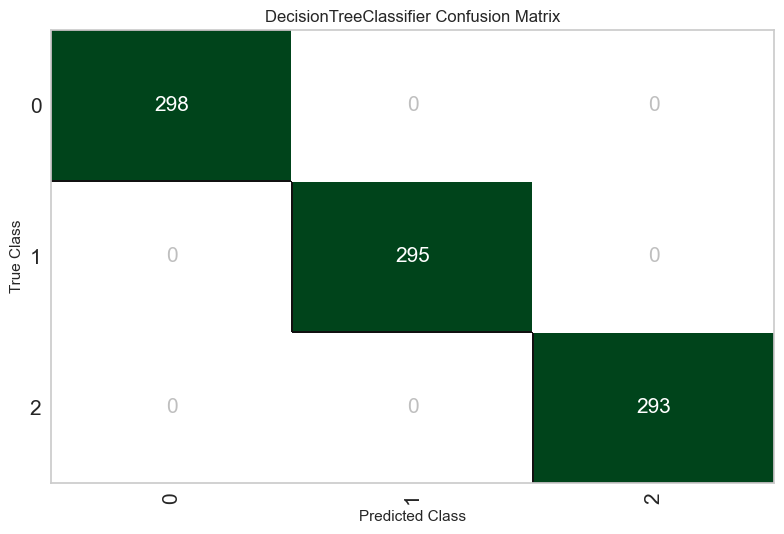

In [102]:
set_current_experiment(exp_clf102)
cls.plot_model(dt2, plot = 'confusion_matrix')

Powyższa macierz pomyłek mówi to, że wszystkie poziomy stresu zostały poprawnie zaklasyfikowane, ponieważ wszystkie wartości znajdują się na głownej przekątnej.

## XAI (Explainable Artificial Intelligence)

XAI to dziedzina sztucznej inteligencji, której celem jest uczynienie działania modeli AI zrozumiałym dla ludzi. Umożliwia interpretację wyników generowanych przez algorytmy, wyjaśnia, dlaczego podejmują one określone decyzje, i zwiększa ich transparentność oraz zaufanie użytkowników.

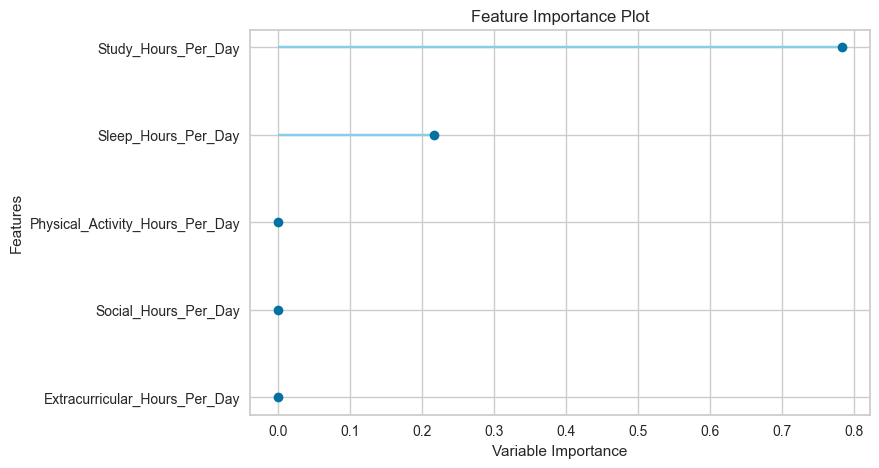

In [103]:
cls.plot_model(dt2, plot='feature')

Wykres Feature Importance przedstawia znaczenie cech w modelu, gdzie największy wpływ na klasyfikacje ma liczba godzin nauki na dzień, a następnie liczba godzin snu. Pozostałe cechy, takie jak aktywność fizyczna, godziny towarzyskie i zajęcia dodatkowe, nie mają wpływu na poziom stresu. Sugeruje to, że model opiera się głównie na dwóch pierwszych cechach, a inne mogą być mniej istotne dla przewidywań. Można interpretować to w taki sposób, żeby przewidzieć poziom stresu ważny jest czas poświęcany na nauke i liczba godzin snu.

## Wizualizacja drzewa

[Text(0.5, 0.875, 'Study_Hours_Per_Day <= 5.95\ngini = 0.667\nsamples = 2066\nvalue = [694, 688, 684]\nclass = High'),
 Text(0.25, 0.625, 'Sleep_Hours_Per_Day <= 5.95\ngini = 0.106\nsamples = 729\nvalue = [41, 688, 0]\nclass = Moderate'),
 Text(0.125, 0.375, 'gini = 0.0\nsamples = 41\nvalue = [41, 0, 0]\nclass = High'),
 Text(0.375, 0.375, 'gini = 0.0\nsamples = 688\nvalue = [0, 688, 0]\nclass = Moderate'),
 Text(0.75, 0.625, 'Study_Hours_Per_Day <= 8.05\ngini = 0.5\nsamples = 1337\nvalue = [653, 0, 684]\nclass = Low'),
 Text(0.625, 0.375, 'Sleep_Hours_Per_Day <= 5.95\ngini = 0.271\nsamples = 816\nvalue = [132, 0, 684]\nclass = Low'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 132\nvalue = [132, 0, 0]\nclass = High'),
 Text(0.75, 0.125, 'gini = 0.0\nsamples = 684\nvalue = [0, 0, 684]\nclass = Low'),
 Text(0.875, 0.375, 'gini = 0.0\nsamples = 521\nvalue = [521, 0, 0]\nclass = High')]

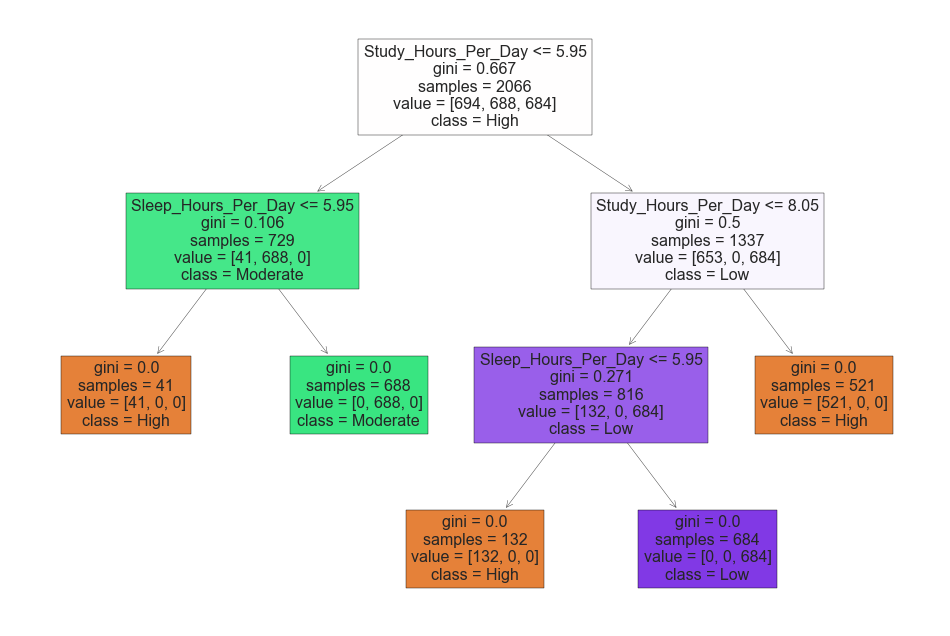

In [104]:
feature_names=X_resampled.columns
plt.figure(figsize=(12, 8))
plot_tree(dt2, feature_names=feature_names, class_names=['High','Moderate','Low'], filled=True)

Drzewo decyzyjne przedstawia podziały danych według cech Study_Hours_Per_Day i Sleep_Hours_Per_Day, które wpływają na klasyfikację. Każdy węzeł zawiera: 
* Cechę używaną do podziału 
* Wartość progu 
* Wartość wskaźnika gini (miara czystości podziału, gdzie 0 oznacza idealną separację klas) 
* Liczbę próbek (samples)
* Liczebność klas (value) 
* Dominującą klasę (class)

W drzewie decyzyjnym, przejście w lewo następuje, gdy warunek w węźle jest spełniony, natomiast przejście w prawo ma miejsce, gdy warunek nie jest spełniony. Na pierwszym podziale dane są rozdzielane według Study_Hours_Per_Day <= 5.95, a następnie podział kontynuowany jest w zależności od wartości cechy snu i godzin nauki. Liście drzewa czyli kolorowe prostokąty oznaczają końcowe decyzje z idealną czystością ponieważ wartość gini równa się zeru.

## Decision Path

Dla lepszego zrozumienia działania naszego drzewa zdecydowaliśmy się utworzyć przykładową ścieżke dla jednej obserwacji. Jako przykład została użyta obserwacja o indexie 164.

In [105]:
sample_index = 164
sample = X_resampled.iloc[sample_index].values.reshape(1, -1)

node_indicator = dt2.decision_path(sample)

feature = dt2.tree_.feature
threshold = dt2.tree_.threshold

print(f"Ścieżka decyzyjna dla próbki nr {sample_index + 1}:")
for node_id in node_indicator.indices:
    if feature[node_id] != -2:  
        feature_name =  X_resampled.columns[feature[node_id]]
        feature_value = sample[0, feature[node_id]]
        threshold_value = threshold[node_id]
        
        direction = "<=" if feature_value <= threshold_value else ">"
        print(f"Node {node_id}: {feature_name} ({feature_value:.3f}) {direction} {threshold_value:.3f}")


print(f"Poziom stresu: {y_resampled.iloc[sample_index]}")

Ścieżka decyzyjna dla próbki nr 165:
Node 0: Study_Hours_Per_Day (8.200) > 5.950
Node 4: Study_Hours_Per_Day (8.200) > 8.050
Poziom stresu: High


 Najpierw pobieramy dane próbki na podstawie jej indeksu z ramki danych X_resampled_df i przekształca je w odpowiedni format do analizy. Następnie oblicza ścieżkę decyzyjną, czyli wszystkie węzły drzewa, przez które przechodzi próbka, korzystając z funkcji decision_path.

W kolejnych krokach dla każdego węzła sprawdza czy nie jest on liściem i która cecha była użyta do podziału oraz jaki był próg wartości. Dla każdego węzła określa, czy wartość cechy dla próbki była mniejsza, równa, czy większa od tego progu, i wyświetla szczegółowy opis tego podziału. Informacja obejmuje numer węzła, nazwę cechy, jej wartość w próbce, kierunek podziału (mniejsze lub większe od progu) oraz wartość tego progu. Na końcu funkcja wyświetla klasę (np. poziom stresu) przypisaną do analizowanej próbki na podstawie danych y_resampled.

Dla naszego przykładu próbka o indeksie 164 na wizualizacji przeszła dwa razy w prawo ponieważ nie spełniła warunku w węźle godziny uczenia były większe od 5.95 w węźle nr 0 i większe od 8.05 w węźle nr 4. Dlatego próbka została zakwalifikowana jaka poziom stresu wysoki. 

#  Partial Dependence Plot (PDP)

Partial Dependence to technika wizualizacji, która pozwala zrozumieć, jak zmiany jednej zmiennej wpływają na prognozy modelu, przy założeniu, że inne cechy pozostają stałe. W skrócie, PD pokazuje, w jaki sposób zmiana wartości jednej cechy wpływa na przewidywania modelu, średnio dla wszystkich innych cech.

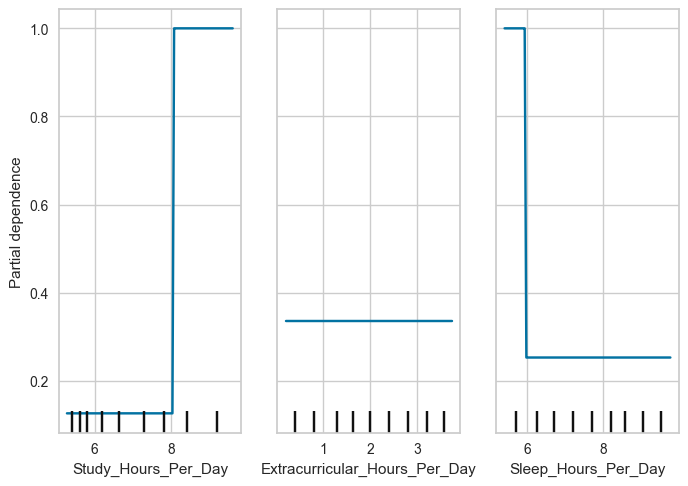

In [106]:
PartialDependenceDisplay.from_estimator(
    estimator=dt2, 
    X=X_resampled, 
    features=[0, 1,2],  
    feature_names=feature_names,
    target=0, 
)

Na pierwszym wykresie widać gwałtowny wzrost "partial dependence" w okolicy 8 godzin nauki. Wskazuje to, że liczba godzin nauki powyżej pewnego poziomu może być silnie powiązana z wyższym poziomem stresu.

Środkowy wykres potwierdza wcześniej postawioną hipoteze mówiącą o tym, że liczba godzin zajęć dodatkowych na dzień nie ma wpływu na poziom stresu w naszym modelu ponieważ jest to pozioma linia.

Trzeci wykres ilustruje odwrotną zależność – przy mniejszej liczbie godzin snu (poniżej 7 godzin), poziom stresu jest wyższy. Więcej snu obniża poziom stresu.

## PCA

**PCA** (Principal Component Analysis) - czyli analiza głównych składowych to metoda redukcji wymiarowości danych przydatna w analizie statystycznej i uczeniu maszynowym. Celem PCA jest zmiejszenie wymiarowości danych przy jednoczesnym zachowaniu jak najwiekszej ilości informacji o zbiorze. PCA działa poprzez identyfikację kierunków największej wariancji w danych, które są reprezentowane jako wektory własne odpowiadające największym wartościom własnym macierzy kowariancji danych.

Pierwsza główna składowa wyznacza kierunek o największej wariancji, druga składowa – prostopadła do pierwszej – wyznacza kierunek o następnej największej wariancji, i tak dalej. Dzięki temu, można zachować istotną ilość informacji w danych, jednocześnie redukując ich liczbę wymiarów, co przyspiesza dalsze analizy i modelowanie.

In [107]:
np.set_printoptions(precision=4)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(dane_czyste.drop("Stress_Level", axis=1))


pca = PCA()
pca.fit(X_scaled)


variances = pca.explained_variance_ratio_
print(f"Wariancje: {variances}")

zeros = (variances<0.001).sum()
print(f"Zera: {zeros}")

Wariancje: [3.5934e-01 2.4846e-01 2.0252e-01 1.8969e-01 3.8132e-15]
Zera: 1


Do redukcji wymiarów metodą PCA zakładamy, że próg wyjaśnionej wariancji powinien byc większy niż 90%.

In [108]:
cumulated_variances = variances.cumsum()
print(f"Skumulowana wariancja: {cumulated_variances}")

Skumulowana wariancja: [0.3593 0.6078 0.8103 1.     1.    ]


In [109]:
dim_090 = (cumulated_variances < 0.90).sum() + 1
print(f"Wymiar z wyjaśnioną wariancją większą od 0.90: {dim_090}")

Wymiar z wyjaśnioną wariancją większą od 0.90: 4


Jak widać, 3 wymiary pozwalają wyjaśnić ponad 80% wariancji w zbiorze danych, a 4 wymiary aż 100%. Z tego powodu do dalszej analizy wykorzystamy 4 wymiary.

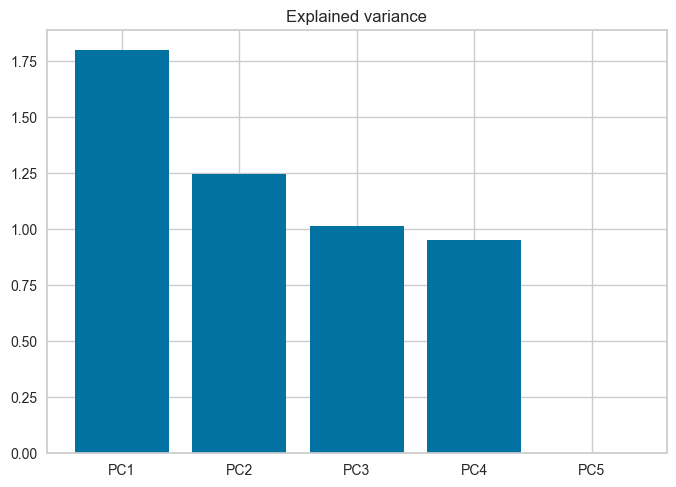

In [110]:
plt.title("Explained variance")
plt.bar(["PC1","PC2","PC3","PC4","PC5"],pca.explained_variance_)
plt.show()

Na wykresie wykresie osypiska widać, że 4 zmienne wystarczą do wyjaśnienia wariancji w zbiorze danych. 

Tworzymy model PCA z 4 składowymi.

In [111]:
pca_090 = PCA(4)
pca_090.fit(X_scaled)

print(f"Number of components: {pca_090.n_components_}")

Number of components: 4


In [112]:
x_transformed_pca = pca_090.transform(X_scaled)

print(f"Oryginalny rozmiar: {X_scaled.shape}")
print(f"Rozmiar po transformacji: {x_transformed_pca.shape}")

Oryginalny rozmiar: (1891, 5)
Rozmiar po transformacji: (1891, 4)


Zapisanie danych po PCA

In [113]:
transformed_pca = pd.DataFrame(x_transformed_pca, columns=["PC1","PC2","PC3","PC4"])
transformed_pca.to_csv("transformed_pca.csv", index=False)

Text(0.5, 0, 'PCA3')

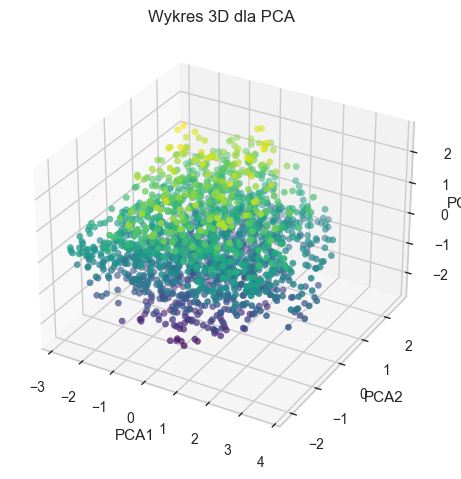

In [114]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(transformed_pca['PC1'], transformed_pca['PC2'], transformed_pca['PC3'], c=transformed_pca['PC3'], cmap='viridis')

ax.set_title("Wykres 3D dla PCA")
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")

## ICA

**ICA** (Independent Component Analysis) czyli analiza niezależnych składowych to algorytm stosowany do oddzielania sygnałów źródłowych poprzez znajdowanie tzw. komponentów niezależnych w danych. W przeciwieństwie do PCA, który koncentruje się na maksymalizacji wariancji danych i znajduje składowe ortogonalne, ICA dąży do maksymalizacji niezależności statystycznej składowych. ICA zakłada, że mieszane sygnały są statystycznie niezależne i mają rozkłady inne niż normalny, co pozwala skutecznie identyfikować różne źródła sygnałów.

In [115]:
ica_3 = FastICA(4)
ica_3.fit(X_scaled)

x_transformed_ica = ica_3.transform(X_scaled)

print(f"Oryginalny rozmiar: {X_scaled.shape}")
print(f"Rozmiar pod transformacji: {x_transformed_ica.shape}")


Oryginalny rozmiar: (1891, 5)
Rozmiar pod transformacji: (1891, 4)


Zapisanie danych po ICA

In [116]:
transformed_ica = pd.DataFrame(x_transformed_ica, columns=["IC1","IC2","IC3","IC4"])
transformed_ica.to_csv("transformed_ica.csv", index=False)

In [117]:
fig = px.scatter_3d(transformed_ica, x='IC1', y='IC2', z='IC3', color='IC3', 
                    title="Interaktywny wykres 3D dla ICA", 
                    labels={'ICA1': 'X', 'ICA2': 'Y', 'ICA3': 'Z'})

fig.show()

Dodanie kolumny Stress_Level do danych po pca i po ica

In [118]:
transformed_ica['Stress_Level'] = dane_czyste['Stress_Level'].values
transformed_pca['Stress_Level'] = dane_czyste['Stress_Level'].values

## Modele na danych po PCA

In [119]:
exp_pca = cls.setup(data = transformed_pca, target = 'Stress_Level') 
cls.compare_models()

,Description,Value
0,Session id,7190
1,Target,Stress_Level
2,Target type,Multiclass
3,Target mapping,"High: 0, Low: 1, Moderate: 2"
4,Original data shape,"(1891, 5)"
5,Transformed data shape,"(1891, 5)"
6,Transformed train set shape,"(1323, 5)"
7,Transformed test set shape,"(568, 5)"
8,Numeric features,4
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9456,0.9925,0.9456,0.9466,0.9453,0.9078,0.9086,0.0410
rf,Random Forest Classifier,0.9305,0.9885,0.9305,0.9318,0.9301,0.8824,0.8836,0.0610
lightgbm,Light Gradient Boosting Machine,0.9297,0.9922,0.9297,0.9309,0.9293,0.8810,0.8820,0.1830
xgboost,Extreme Gradient Boosting,0.9274,0.9906,0.9274,0.9287,0.9272,0.8772,0.8783,0.0340
knn,K Neighbors Classifier,0.9214,0.9892,0.9214,0.9227,0.9205,0.8661,0.8675,0.0140
qda,Quadratic Discriminant Analysis,0.9131,0.0000,0.9131,0.9207,0.9120,0.8519,0.8574,0.0080
gbc,Gradient Boosting Classifier,0.9085,0.0000,0.9085,0.9097,0.9079,0.8441,0.8454,0.1260
dt,Decision Tree Classifier,0.8443,0.8737,0.8443,0.8474,0.8443,0.7374,0.7388,0.0090
lr,Logistic Regression,0.8405,0.0000,0.8405,0.8416,0.8398,0.7300,0.7313,0.0110
lda,Linear Discriminant Analysis,0.8186,0.0000,0.8186,0.8256,0.8193,0.6917,0.6935,0.0090


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=7190, verbose=0,
                     warm_start=False)

## Modele na danych po ICA

In [120]:
exp_ica = cls.setup(data = transformed_ica, target = 'Stress_Level')
cls.compare_models()

,Description,Value
0,Session id,3158
1,Target,Stress_Level
2,Target type,Multiclass
3,Target mapping,"High: 0, Low: 1, Moderate: 2"
4,Original data shape,"(1891, 5)"
5,Transformed data shape,"(1891, 5)"
6,Transformed train set shape,"(1323, 5)"
7,Transformed test set shape,"(568, 5)"
8,Numeric features,4
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9887,0.9993,0.9887,0.9888,0.9886,0.9809,0.9810,0.1790
et,Extra Trees Classifier,0.9879,0.9996,0.9879,0.9882,0.9878,0.9795,0.9797,0.0410
rf,Random Forest Classifier,0.9871,0.9994,0.9871,0.9873,0.9871,0.9783,0.9784,0.0570
xgboost,Extreme Gradient Boosting,0.9849,0.9996,0.9849,0.9852,0.9849,0.9745,0.9746,0.0190
gbc,Gradient Boosting Classifier,0.9826,0.0000,0.9826,0.9828,0.9826,0.9706,0.9708,0.1180
dt,Decision Tree Classifier,0.9818,0.9840,0.9818,0.9822,0.9817,0.9693,0.9696,0.0090
knn,K Neighbors Classifier,0.9319,0.9891,0.9319,0.9322,0.9316,0.8847,0.8851,0.0130
qda,Quadratic Discriminant Analysis,0.9214,0.0000,0.9214,0.9267,0.9206,0.8665,0.8701,0.0080
nb,Naive Bayes,0.9002,0.9779,0.9002,0.9061,0.8997,0.8317,0.8348,0.0090
lr,Logistic Regression,0.8472,0.0000,0.8472,0.8476,0.8465,0.7412,0.7424,0.0090


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=3158, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)

In [121]:
lightgbm = cls.create_model('lightgbm')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.9850,0.9972,0.9850,0.9850,0.9850,0.9745,0.9745
2,0.9925,0.9996,0.9925,0.9929,0.9925,0.9873,0.9874
3,0.9848,1.0000,0.9848,0.9853,0.9848,0.9741,0.9745
4,0.9924,0.9993,0.9924,0.9925,0.9924,0.9872,0.9873
5,0.9773,0.9994,0.9773,0.9775,0.9773,0.9620,0.9621
6,0.9924,0.9991,0.9924,0.9925,0.9924,0.9872,0.9873
7,0.9848,0.9999,0.9848,0.9852,0.9849,0.9746,0.9747
8,0.9924,0.9999,0.9924,0.9925,0.9923,0.9872,0.9873


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

Modele trenowane na danych po ICA dały lepsze wyniki niż po PCA. Udało nam się zachować bardzo dobrą zdolność predykcyjną modeli (najlepszy model ma blisko 100% accuracy) przy jednoczesnej redukcji wymiarowości zbioru danych.

Pokażemy jeszcze macierz pomyłek aby zobaczyc w jakim przypadku model błędnie zklasyfikował.

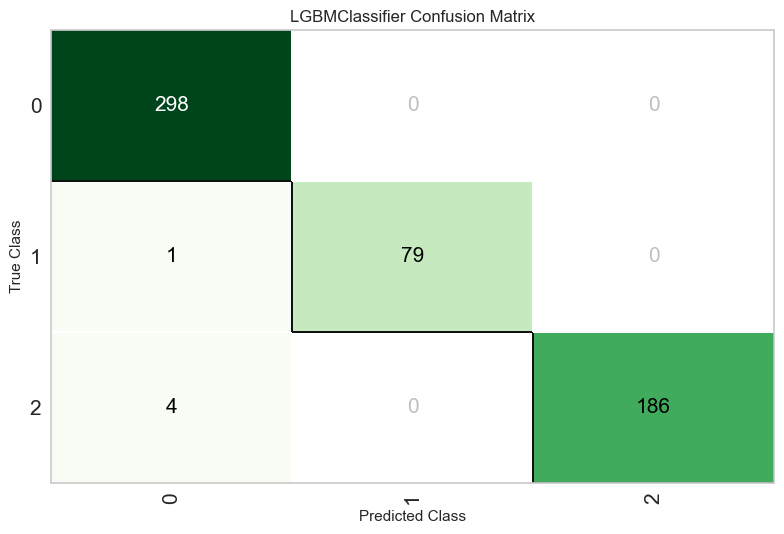

In [122]:
set_current_experiment(exp_ica)
cls.plot_model(lightgbm, plot = 'confusion_matrix')

## Podsumowanie

Na początku projektu zaimportowaliśmy dane i przeprowadziliśmy wstępną analizę. Zostały wyliczone podstawowe statystyki, sprawdziliśmy rozkłady badanych zmiennych i znaleźliśmy zależnści między nimi.

Przeprowadziliśmy wstepne uczenie modeli aby ustalić początkowy poziom ich skuteczności. Modele okazały się bardzo skuteczne już na początku.

Następnie oczyściliśmy zbiór danych z nieporządanych obserwacji. Usunęliśmy wartości odstające korzystając z IQR, usunęliśmy zmienne o małej wariancji oraz wykorzystaliśmy bibliotekę PyCaret do wykrycia anaomalii które również zostały usunięte.

Aby zrównoważyć dane, zastosowaliśmy technikę ADASYN, która generuje sztuczne przykłady dla klasy mniejszościowej. Dzięki temu uzyskaliśmy zrównoważony zbiór danych, który zawierał około 1000 obserwacji dla każdej z klas poziomu stresu.

Na zrównoważonym i oczyszczonym zbiorze danych przeprowadziliśmy eksperymenty z różnymi modelami klasyfikacyjnymi za pomocą biblioteki PyCaret. Porównaliśmy wyniki różnych modeli, a następnie stworzyliśmy i dostroiliśmy model drzewa decyzyjnego, który osiągnął idealne wyniki klasyfikacji.

Aby poprawić wyniki modeli, dodaliśmy nową zmienną będącą liczbą godzin snu podniesioną do sześcianu. Ponowne eksperymenty z nową zmienną, nie przyniosły znaczącej poprawy wyników modeli.

Wykorzystaliśmy techniki XAI, aby wyjaśnić działanie modelu. Przeprowadziliśmy wizualizację drzewa decyzyjnego oraz pokazaliśmy jak przykładowa próbka jest klesyfikowana do odpowiedniej klasy. Wykonanaliśmy również wykres Feature Importance, który pokazał, że liczba godzin nauki i snu mają największy wpływ na klasyfikację poziomu stresu.

Zastosowaliśmy techniki PCA oraz ICA do redukcji wymiarowości danych. Przeprowadziliśmy eksperymenty z modelami klasyfikacyjnymi na danych po PCA i ICA, uzyskując bardzo dobre wyniki, szczególnie na danych po ICA.

W trakcie projektu zapisywaliśmy przetworzone dane do plików csv.

Projekt zakończył się sukcesem, udało nam się bardzo dokładnie przewidywać poziom stresu u uczniów na podstawie danych dotyczących ich stylu życia, co było celem naszego projektu.
Przy okazji odkryliśmy co wpływa na poziom stresu. Im więcej czasu na nauke poświecają studienci tym są bardziej zestresowani oraz, że wzrost czasu poświęconego na sen łagodzi poziom stresu.

Podsumowując, nasza praca doprowadziła nas do kilku ciekawych wniosków na temat czynników wpływających na poziom stresu u studentów.Analizy wykazały, że choć nie wszystkie wprowadzone zmienne poprawiły dokładność modeli, niektóre z nich znacząco poszerzyły nasze rozumienie mechanizmów związanych ze stresem. Ostatecznie uzyskane rezultaty mogą posłużyć jako baza do projektowania strategii wspierających studentów w zarządzaniu stresem, uwzględniających zarówno aspekty fizyczne, jak i psychologiczne.